# Download and enrich data

metadata for each task = list of entities

entitiy: dict

Inicial set: ~300 entities to be partially enriched

Enriched set: fully enriched and verified, including manual checks/inputs.
Manually remove mismaches name<->pantheon.

Filtered set: filtered 100 entities based on representativenss balancing

Entities appear exactly in this order in the table representations.

Images should only be saved for the entities in the final enriched set


In [ ]:
import os
import sys
import math
import dotenv
import pandas as pd
import scipy.io as sio
import torch.utils.checkpoint


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_colwidth', 30)

sys.path.append('../TRDP-unlearning')
dotenv.load_dotenv('../TRDP-unlearning/SD_lora_distil/.env')
os.environ['WANDB_DISABLED'] = "true"
assert len(os.getenv('HF_TOKEN'))>0
#!huggingface-cli login --token ${HF_TOKEN}

from vision_unlearning.utils.logger import get_logger, setup_loggers

from vision_unlearning.datasets import (
    pantheon_find_closest_match,
    download_dataset_pantheon,
    download_dataset_akc,
    akc_find_closest_match,
    count_classes_dataset_taras_breeds,
    download_dataset_taras_breeds,
    split_dataset_taras_breeds,
    split_dataset_sun,
    balanced_subsample_lib
)
from vision_unlearning.datasets.testbed import calculate_similarity_clip, plot_heatmap

logger = get_logger('unlearning_analysis')
setup_loggers(modules_info=['unlearning'])

## Scenes

In [4]:
dataset_base_path = 'assets/datasets/SUN'
dataset_base_path_filtered = 'assets/datasets/SUN_splits_filtered'

#!rm "assets/similarity_clip_scenes.json"
#!rm -rf {dataset_base_path}
#!rm assets/metadata_scenes_1_enriched_but_not_filtered.json && rm assets/metadata_scenes_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
#!rm assets/metadata_scenes_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
#!rm -r {dataset_base_path_filtered}

In [ ]:
import random
import os
import json
import uuid
import shutil
import subprocess
from pathlib import Path
from collections import Counter, defaultdict
from typing import Optional, List, Dict, Tuple
import re
import unicodedata
import urllib.request
import bz2
from PIL import Image

import pandas as pd
import numpy as np
from unidecode import unidecode
from datasets import load_dataset

from vision_unlearning.datasets.base import logger
from vision_unlearning.datasets import create_metadata_jsonl



In [6]:
##############################
# Step 1: prepare datasets
##############################
hierarchy: Dict[str, List[str]] = {
    "Functions/Affordances": [
        "camping",
        "hiking",
        "shopping",
        "farming",
        "studying/ learning",
        "diving",
        "praying",
        "climbing",
        "research",
        "swimming",
        "sports",
        "spectating/ being in an audience",
        "reading",
        "sailing/ boating",
        "driving",
        "conducting business",
        "sunbathing",
        "socializing",
        "eating",
        "waiting in line/ queuing",
        "teaching/ training",
        "working",
        "biking",
        "playing",
        "competing",
        "congregating",
        "transporting things or people",
        "using tools",
        "exercise",
        "vacationing/ touring"
    ],
    "Materials": [
        "foliage",
        "vegetation",
        "shrubbery",
        "trees",
        "leaves",
        "clouds",
        "snow",
        "grass",
        "asphalt",
        "sand",
        "running water",
        "dirt/soil",
        "ocean",
        "shingles",
        "paper",
        "brick",
        "flowers",
        "rock/stone",
        "carpet",
        "still water",
        "rubber/ plastic",
        "wood (not part of a tree)",
        "pavement",
        "cloth",
        "vinyl/ linoleum",
        "glass",
        "concrete",
        "fencing",
        "wire",
        "metal"
    ]
,
    "Surface Properties": [
        "natural light",
        "direct sun/sunny",
        "electric/indoor lighting",
        "dirty",
        "moist/ damp",
        "aged/ worn",
        "glossy",
        "rusty",
        "matte",
        "dry"
    ],
    "Spatial Envelope": [
        "natural",
        "far-away horizon",
        "enclosed area",
        "open area",
        "rugged scene",
        "cold",
        "no horizon",
        "cluttered space",
        "mostly vertical components",
        "stressful",
        "man-made",
        "symmetrical",
        "soothing",
        "warm",
        "semi-enclosed area",
        "mostly horizontal components",
    ]
}

#!rm -rf {dataset_base_path}
if not os.path.exists(os.path.join(dataset_base_path, "SUNAttributeDB")) or not os.path.exists(os.path.join(dataset_base_path, "images")):
    os.makedirs(dataset_base_path, exist_ok=True)
    !wget https://cs.brown.edu/~gmpatter/Attributes/SUNAttributeDB.tar.gz -O {os.path.join(dataset_base_path, "SUNAttributeDB.tar.gz")}
    !wget https://cs.brown.edu/~gmpatter/Attributes/SUNAttributeDB_Images.tar.gz -O {os.path.join(dataset_base_path, "SUNAttributeDB_Images.tar.gz")}
    !tar -xzf {os.path.join(dataset_base_path, "SUNAttributeDB.tar.gz")} -C {dataset_base_path}
    !tar -xzf {os.path.join(dataset_base_path, "SUNAttributeDB_Images.tar.gz")} -C {dataset_base_path}

attributes: List[str] = [f[0][0] for f in sio.loadmat(os.path.join(dataset_base_path, "SUNAttributeDB/attributes.mat"))['attributes'].tolist()]
filenames: List[str] = [f[0][0] for f in sio.loadmat(os.path.join(dataset_base_path, "SUNAttributeDB/images.mat"))['images'].tolist()]

df = pd.DataFrame(
    sio.loadmat(os.path.join(dataset_base_path, "SUNAttributeDB/attributeLabels_continuous.mat"))['labels_cv'],
    index=filenames,
    columns=attributes,
)
df = df>0.5  # Convert continuous to binary; 2 out of 3 labelers agree with the label
df['category'] = pd.Series(df.index, index=df.index).str.split('/').apply(lambda parts: '_'.join(parts[1:-1]))
print(df.shape)

# assert sum([len(hierarchy[k]) for k in hierarchy]) == df.shape[1]-1, 'Not all attributes are mapped in the hierarchy'
assert all([all([att in df.columns for att in hierarchy[k]]) for k in hierarchy]), 'There are attributes that dont exist'

(14340, 103)


In [7]:
##############################
# Step 2: attribute inference
##############################

#!rm assets/metadata_scenes_1_enriched_but_not_filtered.json && rm assets/metadata_scenes_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
if os.path.exists('assets/metadata_scenes_1_enriched_but_not_filtered.json'):
    with open(f"assets/metadata_scenes_1_enriched_but_not_filtered.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
else:
    # Attribute inference option 1:labels from SUN itself
    # Not present

    # Attribute inference option 2: from another dataset
    # Not found. TODO

    # Attribute inference option 3: average value in SUN dataset
    df_categories = df.groupby('category').mean()
    print((df_categories>0.1).mean().mean()*100)
    print((df_categories>0.5).mean().mean()*100)
    print((df_categories>0.8).mean().mean()*100)
    df_categories = df_categories>0.5   # At least x% of the instances have this property

    df_categories.reset_index(inplace=True)
    df_categories.rename({'category': 'name'}, axis=1, inplace=True)
    df_categories['dataset_n_original'] = 20
    metadata = df_categories.to_dict(orient='records')
    
    # Save
    with open(f"assets/metadata_scenes_1_enriched_but_not_filtered.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

In [8]:
##############################
# Step 3: filter
##############################

# Some interesting attributes:
#df_categories.value_counts(['socializing', 'natural'])
#df_categories.value_counts(['socializing', 'open area'])
#df_categories.value_counts(['exercise', 'natural'])
#df_categories.value_counts(['sports', 'natural'])
#df_categories.value_counts(['sports', 'open area'])
#df_categories[df_categories['man-made'] & df_categories['ocean']]
#df_categories.value_counts(['driving', 'transporting things or people'])

#!rm assets/metadata_scenes_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
balanced_n = 100

if os.path.exists('assets/metadata_scenes_2_enriched_filtered.json'):
    logger.info('Reading existing filtered data')
    with open(f"assets/metadata_scenes_2_enriched_filtered.json", "r", encoding="utf-8") as f:
        metadata_filtered = json.load(f)
else:
    logger.info('Filtering')
    with open(f"assets/metadata_scenes_1_enriched_but_not_filtered.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)

    df_enriched = pd.DataFrame(metadata)
    print(f"Rows in unfiltered dataset: {df_enriched.shape[0]}")

    ########################
    # make ideal choice of attributes to balance, constrained to one of "Functions/Affordances" and another from "Spatial Envelope" category groups
    # This sequential optimization is suboptimal... but is probably good enough, and I like the selected attributes
    min_1 = 0
    min_1_att = None
    for att_1 in hierarchy["Functions/Affordances"]:
        min_current = df_enriched.value_counts([att_1]).min()
        if min_current > min_1 and min_current != df_enriched.value_counts([att_1]).max():
            min_1 = min_current
            min_1_att = att_1
    print(f"First selected attributes: {min_1_att}, with min count {min_1}")

    min_2 = 0
    min_2_att = None
    for att_2 in hierarchy["Spatial Envelope"]:
        #if att_2 in ['man-made', 'natural']:
        #    continue#
        if df_enriched[att_2].nunique() == 1:
            continue
        #if len(df_enriched.value_counts([min_1_att, att_2])) < 4:
        #    continue
        min_current = df_enriched.value_counts([min_1_att, att_2]).min()
        if min_current > min_2:
            min_2 = min_current
            min_2_att = att_2
    print(f"Second selected attributes: {min_2_att}, with min count {min_2}")
    ########################

    print('BEFORE BALANCING')
    df_enriched.dropna(subset=[min_1_att, min_2_att], axis=0, inplace=True)
    print(df_enriched.value_counts(min_1_att))
    print("-"*50)
    print(df_enriched.value_counts(min_2_att))
    print("-"*50)
    counts = df_enriched.value_counts([min_1_att, min_2_att])
    print(counts)
    print(f"Rows after dropping rows that could not be enriched: {df_enriched.shape[0]}")
    print(f"Need {math.ceil(100/len(counts))}, have min {counts.min()}")

    df_balanced = balanced_subsample_lib(df_enriched, group_cols=[min_1_att, min_2_att], target=balanced_n, priority_col='dataset_n_original')
    print('-'*50)
    print('-')
    print('-'*50)
    print('BALANCED')

    print(df_balanced.value_counts(min_1_att))
    print('-'*50)
    print(df_balanced.value_counts(min_2_att))
    print('-'*50)
    print(df_balanced.value_counts([min_1_att, min_2_att]))

    metadata_filtered = df_balanced.to_dict(orient='records')
    with open(f"assets/metadata_scenes_2_enriched_filtered.json", "w", encoding="utf-8") as f:
        json.dump(metadata_filtered, f, indent=2)

assert type(metadata_filtered) == list
assert len(metadata_filtered) == balanced_n


[2025-11-07 20:07:16 +0100] vision_unlearning.datasets INFO     Reading existing filtered data


In [9]:
##############################
# Step 4: save splits
##############################
smallest_entity = min([entity['dataset_n_original'] for entity in metadata_filtered])
restrict_labels = [e['name'] for e in metadata_filtered]
logger.info(f"We have {balanced_n} identities, each one with {smallest_entity} images")

#!rm -r {dataset_base_path_filtered}
if not os.path.exists(dataset_base_path_filtered):
    for i, target in enumerate(restrict_labels):
        logger.info(f"Saving split dataset for entity {i}: {target}")
        dataset_forget_name = f"{dataset_base_path_filtered}/{target}/train_forget"
        dataset_retain_name = f"{dataset_base_path_filtered}/{target}/train_retain"
        class_to_number = split_dataset_sun(
            dataset_base_path,
            dataset_forget_name,
            dataset_retain_name,
            target,
            forget_max_img = smallest_entity,
            retain_max_img_per_class= smallest_entity,
            restrict_labels = restrict_labels,
        )
        assert sum([v>0 for v in class_to_number.values()]) == balanced_n, 'More entities than expected were saved'
        assert sum([v==smallest_entity for v in class_to_number.values()]) == balanced_n, 'Not all entities have the same number of images'
        assert target in class_to_number.keys()
    
        assert sum(len(files) for _, _, files in os.walk(dataset_forget_name)) == smallest_entity+1
        assert sum(len(files) for _, _, files in os.walk(dataset_retain_name)) == (balanced_n-1)*smallest_entity+1

        #if i > 5:
        #    break

# Each identity has about 8.2Mb
#!du -hs "{dataset_base_path_filtered}/{target}"

#!find "{dataset_forget_name}" \( -type f -o -type l \) | wc -l
#!find "{dataset_retain_name}"  \( -type f -o -type l \) | wc -l

[2025-11-07 20:07:17 +0100] vision_unlearning.datasets INFO     We have 100 identities, each one with 20 images


In [10]:
#restrict_labels

Analying similarities for entity_emitter=abbey
Analying similarities for entity_emitter=waterfall_cascade
Analying similarities for entity_emitter=velodrome_outdoor
Analying similarities for entity_emitter=volleyball_court_outdoor
Analying similarities for entity_emitter=arena_hockey
Analying similarities for entity_emitter=arena_basketball
Analying similarities for entity_emitter=terrace_farm
Analying similarities for entity_emitter=tree_farm
Analying similarities for entity_emitter=tundra
Analying similarities for entity_emitter=valley
Analying similarities for entity_emitter=stone_circle
Analying similarities for entity_emitter=volcano
Analying similarities for entity_emitter=waterfall_cataract
Analying similarities for entity_emitter=pavilion
Analying similarities for entity_emitter=waterfall_fan
Analying similarities for entity_emitter=waterfall_plunge
Analying similarities for entity_emitter=watering_hole
Analying similarities for entity_emitter=wave
Analying similarities for ent

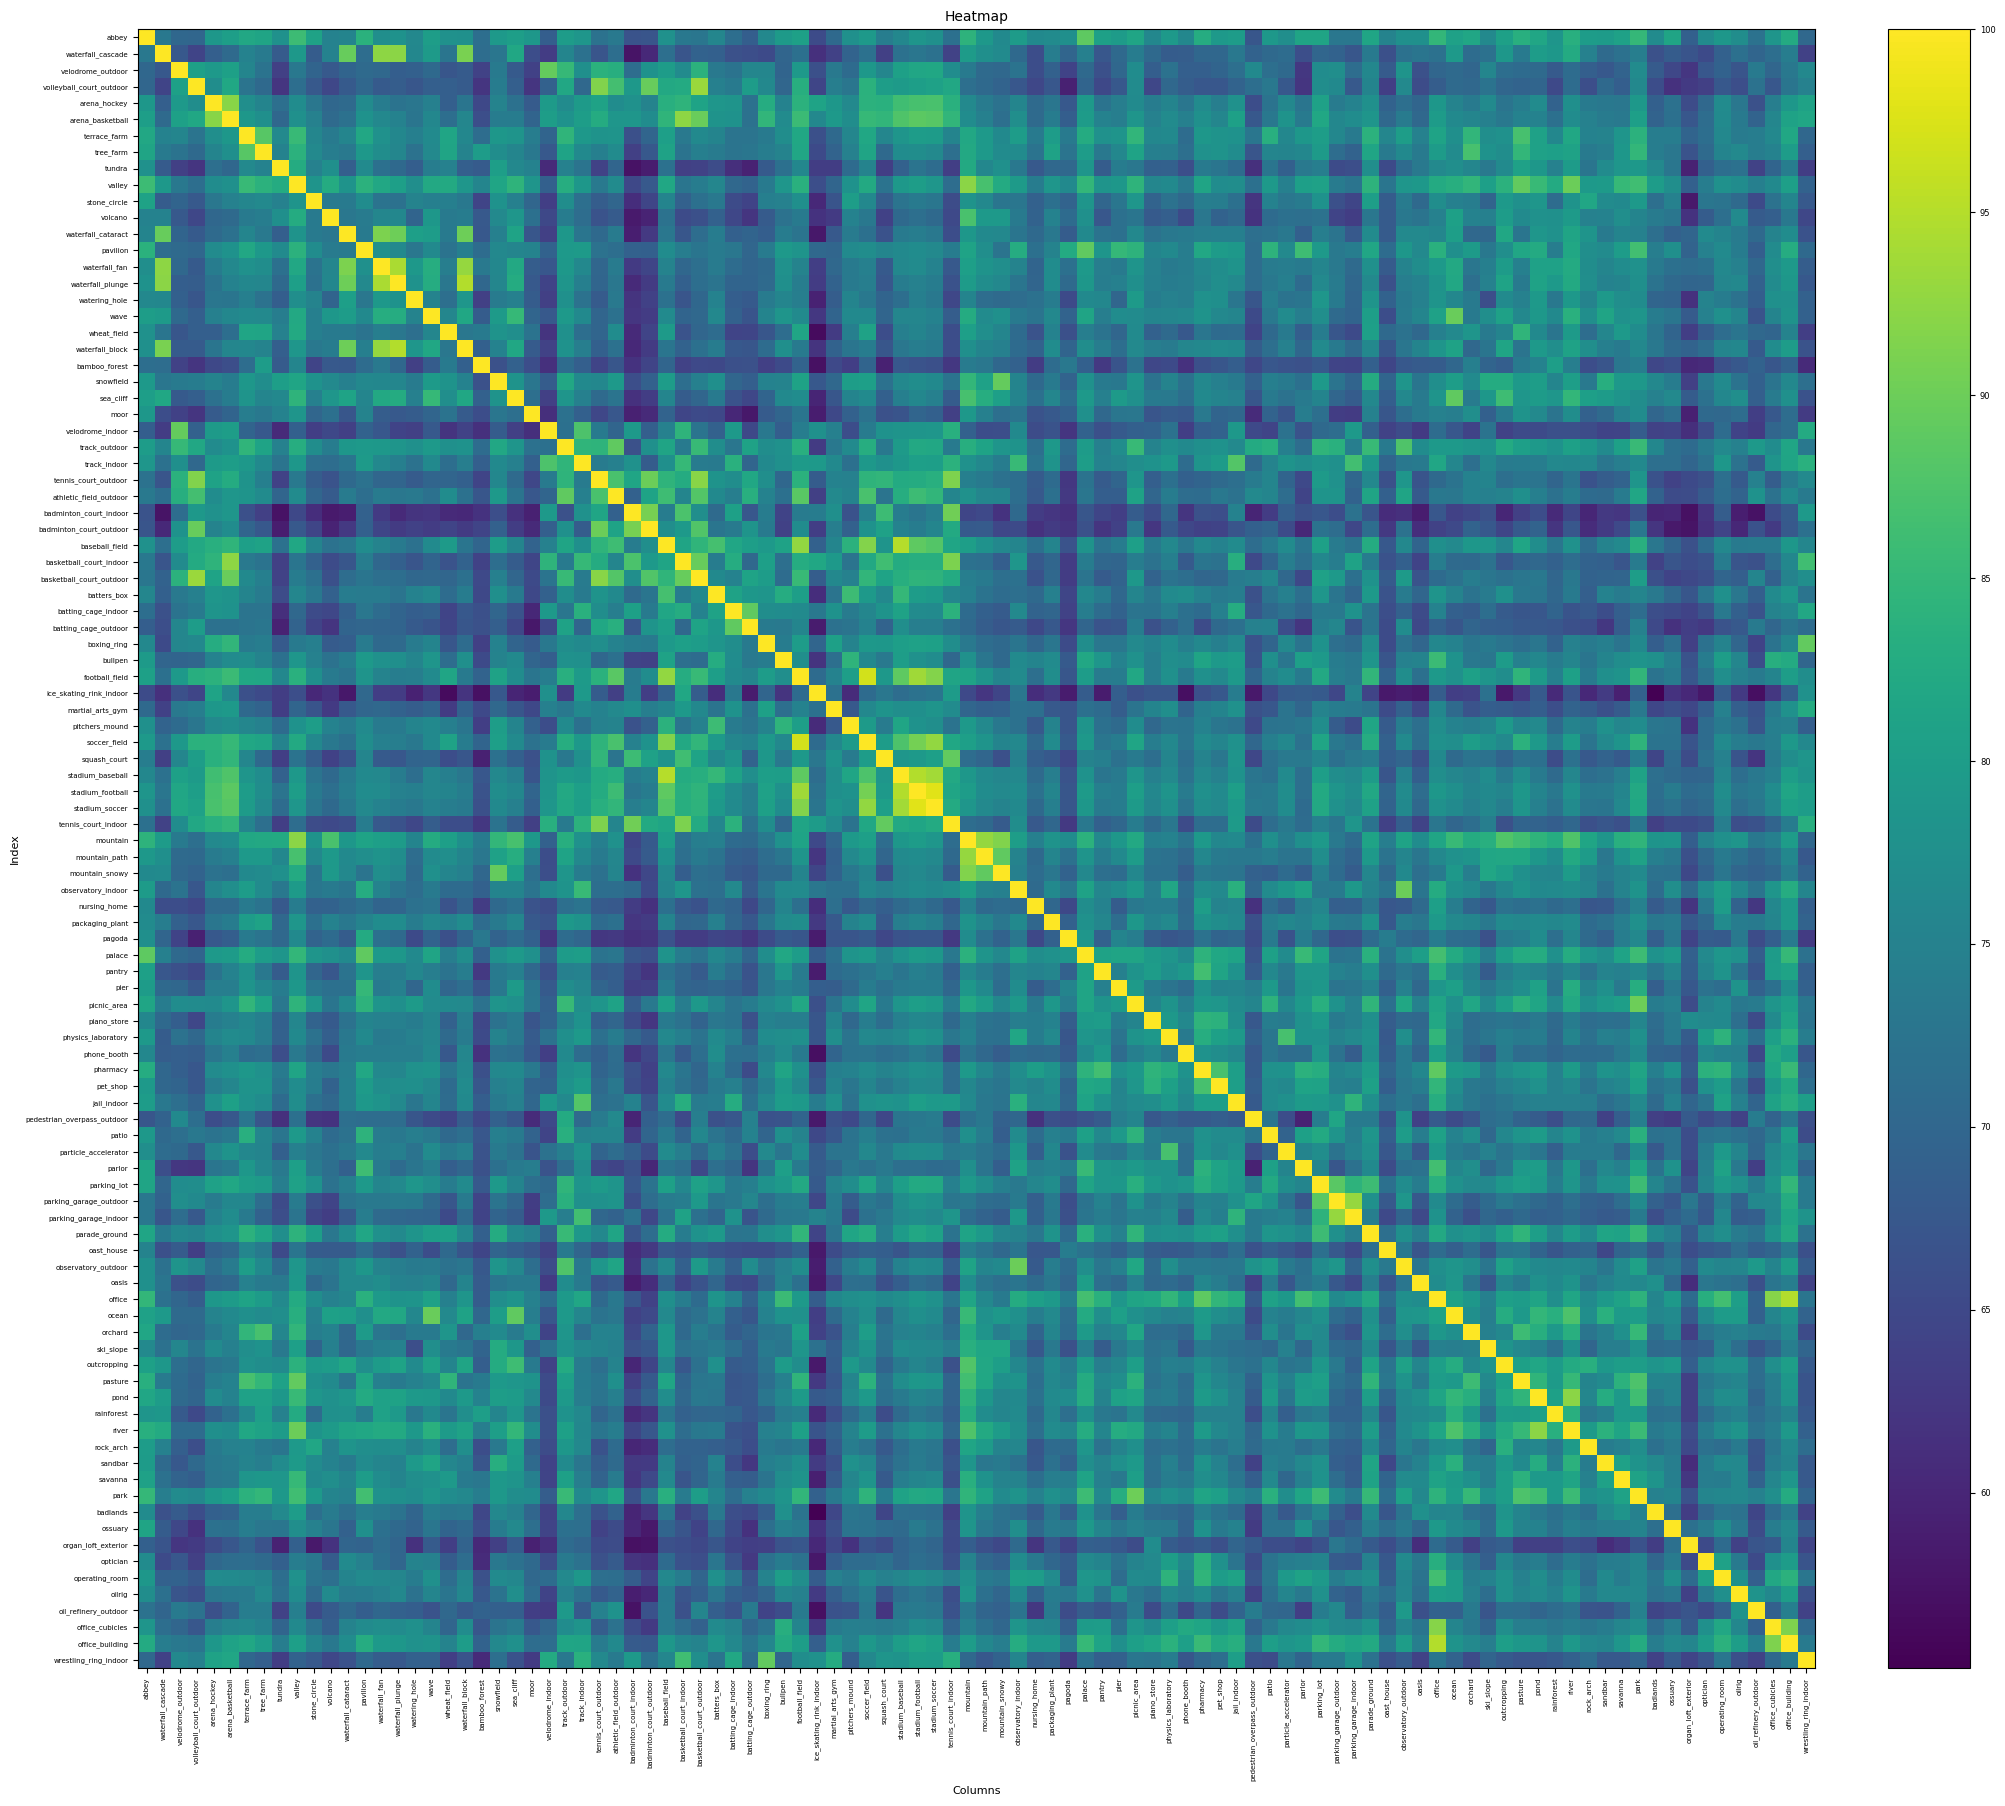

,abbey,waterfall_cascade,velodrome_outdoor,volleyball_court_outdoor,arena_hockey,arena_basketball,terrace_farm,tree_farm,tundra,valley,stone_circle,volcano,waterfall_cataract,pavilion,waterfall_fan,waterfall_plunge,watering_hole,wave,wheat_field,waterfall_block,bamboo_forest,snowfield,sea_cliff,moor,velodrome_indoor,track_outdoor,track_indoor,tennis_court_outdoor,athletic_field_outdoor,badminton_court_indoor,badminton_court_outdoor,baseball_field,basketball_court_indoor,basketball_court_outdoor,batters_box,batting_cage_indoor,batting_cage_outdoor,boxing_ring,bullpen,football_field,ice_skating_rink_indoor,martial_arts_gym,pitchers_mound,soccer_field,squash_court,stadium_baseball,stadium_football,stadium_soccer,tennis_court_indoor,mountain,mountain_path,mountain_snowy,observatory_indoor,nursing_home,packaging_plant,pagoda,palace,pantry,pier,picnic_area,piano_store,physics_laboratory,phone_booth,pharmacy,pet_shop,jail_indoor,pedestrian_overpass_outdoor,patio,particle_accelerator,parlor,parking_lot,parking_garage_outdoor,parking_garage_indoor,parade_ground,oast_house,observatory_outdoor,oasis,office,ocean,orchard,ski_slope,outcropping,pasture,pond,rainforest,river,rock_arch,sandbar,savanna,park,badlands,ossuary,organ_loft_exterior,optician,operating_room,oilrig,oil_refinery_outdoor,office_cubicles,office_building,wrestling_ring_indoor
emitter,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
abbey,99.999985,73.096939,70.248764,70.001480,78.852707,80.323730,81.987251,81.447701,77.839355,85.937103,81.103935,75.080002,75.385178,83.774445,77.413277,77.981224,76.186394,80.125504,77.809349,77.637802,71.360283,79.383904,80.252678,78.882652,68.658707,80.016388,78.667801,72.096428,73.325790,66.670586,67.002899,77.901268,73.223907,72.727234,75.834511,71.416580,68.539299,76.105431,79.637497,80.717880,65.418625,70.495811,77.718475,79.399979,74.165878,76.018616,78.527893,77.623001,71.826569,84.174377,79.080620,76.465240,79.724007,76.412033,76.779999,77.461922,88.820221,80.598419,79.737839,81.462288,75.930061,79.211441,75.904556,82.991722,79.426079,80.040489,67.235092,79.172691,77.301338,81.302437,81.307068,73.050186,72.898499,81.506058,75.199722,77.737534,77.768127,84.817642,80.905251,81.655327,76.301254,80.618591,83.528992,81.731918,78.549385,83.506622,79.918381,79.830109,80.797806,85.041962,76.856468,81.401428,68.916519,76.867798,78.986824,77.139320,72.090569,78.501801,82.541046,70.284286
waterfall_cascade,73.096939,99.999985,67.567551,64.330093,68.741005,70.723137,75.131264,73.541733,68.025948,79.103157,68.216431,74.983826,89.607689,71.276764,92.317390,92.278084,76.003876,79.692741,72.553558,90.989441,71.183624,72.794090,81.875038,65.738037,63.251305,75.531601,71.967384,67.046356,71.310089,57.555401,60.339470,71.569054,66.994385,69.227615,69.005714,66.359299,65.968712,65.276184,69.739006,71.694122,61.357136,63.796200,69.528648,71.891556,63.725567,71.867378,72.787758,71.833534,64.099937,79.803322,77.456573,76.715530,70.564590,65.863998,74.222084,69.755493,74.685760,67.378304,70.535278,74.026535,70.569702,68.161270,68.378319,70.217163,70.109955,73.140594,69.359795,70.544418,71.006882,65.908440,70.019859,69.260803,67.120216,73.483429,66.070679,71.958443,72.688850,71.889565,79.425583,71.040932,71.916847,78.978195,73.484566,79.943192,78.921822,82.625946,74.866089,70.738312,71.866676,74.442902,66.406036,68.173515,66.807251,65.334267,69.199989,71.715858,69.742737,71.368752,74.106529,63.814266
velodrome_outdoor,70.248764,67.567551,99.999985,80.733482,79.412537,80.625458,75.565529,72.254364,63.637535,73.121521,69.639503,67.741013,69.647400,70.642784,70.375931,68.520790,68.887955,70.581833,67.249535,68.121872,64.109512,73.608467,67.913910,63.934181,89.485344,85.210510,77.457619,83.728996,83.328186,71.186325,78.091087,79.918114,76.730598,84.062233,73.385414,72.227608,75.732719,75.786575,69.568100,79.235580,66.208817,73.285225,70.846962,79.128189,75.847099,80.743530,81.785767,81.903931,76.906998,73.7272

In [ ]:
##############################
# Step 5: similarity matrix
##############################

#!rm "assets/similarity_clip_scenes.json"
df_similarities_clip = calculate_similarity_clip('scenes', restrict_labels)
plot_heatmap(df_similarities_clip)
df_similarities_clip.head()

## Object

In [13]:
'''
# See also https://colab.research.google.com/drive/1wwSvMc7I8qOAWhCnGafSJJAmEyipcLA2#scrollTo=vMthgElB-sZM
#!pip install nltk
import nltk
nltk.download('wordnet')
from nltk.corpus import wordnet as wn
''';

In [14]:
'''
##############################
# Step 1: prepare datasets
##############################
os.makedirs('assets/datasets/imagenet')
is not of.path.exists('assets/datasets/imagenet/attrann.mat'):
    !wget https://www.image-net.org/data/attrann.mat -O assets/datasets/imagenet/attrann.mat
''';

In [15]:
'''
data = sio.loadmat("assets/datasets/imagenet/attrann.mat")['attrann']#.keys()

df = pd.DataFrame(
    data[0][0][2],
    index=[e[0][0] for e in data[0][0][0]],
    columns=[e[0] for e in data[0][0][1][0]]
)
df['category'] = pd.Series(df.index, index=df.index).str.split('_').str[0]
df.head()
''';

In [16]:
# If we wanted to enrich object with category data... eh
#df['hyper1'] = df['category'].apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).hypernyms()[0].name().split('.')[0])
#df['hyper2'] = df['category'].apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).hypernyms()[0].hypernyms()[0].name().split('.')[0])
#df['hyper3'] = df['category'].apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).hypernyms()[0].hypernyms()[0].hypernyms()[0].name().split('.')[0])

#df['category_name'] = df['category'].apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).name().split('.')[0])
#df['category_name'].value_counts()

#df['hyper3'].value_counts().head(20)

#df[df['hyper3']=='instrumentality'].value_counts('category_name').head(20)

In [17]:
##############################
# Step 2: attribute inference
##############################

'''
df_categories = df.groupby('category').mean()
print((df_categories>0.1).mean().mean()*100)
print((df_categories>0.5).mean().mean()*100)
print((df_categories>0.8).mean().mean()*100)
df_categories = df_categories>0.3   # At least x% of the instances have this property
len(df_categories)

# enrich with wordnet
def f(x):
    h4 = wn.synset_from_pos_and_offset('n', int(x[1:])).hypernyms()[0].hypernyms()[0].hypernyms()[0].hypernyms()[0]
    l = h4.hypernyms()
    if len(l)>0:
        return l[0].name().split('.')[0]
    else:
        return h4.name().split('.')[0]
df_categories['hyper1'] = pd.Series(df_categories.index, index=df_categories.index).apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).hypernyms()[0].name().split('.')[0])
df_categories['hyper2'] = pd.Series(df_categories.index, index=df_categories.index).apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).hypernyms()[0].hypernyms()[0].name().split('.')[0])
df_categories['hyper3'] = pd.Series(df_categories.index, index=df_categories.index).apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).hypernyms()[0].hypernyms()[0].hypernyms()[0].name().split('.')[0])
df_categories['hyper4'] = pd.Series(df_categories.index, index=df_categories.index).apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).hypernyms()[0].hypernyms()[0].hypernyms()[0].hypernyms()[0].name().split('.')[0])
df_categories['hyper5'] = pd.Series(df_categories.index, index=df_categories.index).apply(f)

df_categories['category_name'] = pd.Series(df_categories.index, index=df_categories.index).apply(lambda x: wn.synset_from_pos_and_offset('n', int(x[1:])).name().split('.')[0])
''';

In [18]:
'''
cats = ["placental", "animal", "mammal", "chordate", "vertebrate", "ungulate", "organism", "living_thing", "domestic_animal", "aquatic_mammal", "plant", "bony_fish", "plant_organ", "reptile", "primate", "ruminant", "even-toed_ungulate", "foodstuff", "food"]
df_categories2 = df_categories[
    ~df_categories['hyper5'].isin(cats)
    & ~df_categories['hyper4'].isin(cats)
    & ~df_categories['hyper3'].isin(cats)
    & ~df_categories['hyper2'].isin(cats)
    & ~df_categories['hyper1'].isin(cats)
]

print(df_categories2.shape)
df_categories2.head(100).tail(20)
''';

In [19]:
'''
cats = ['vehicle', 'artifact', 'object', 'instrumentality', 'vehicle', 'wheeled_vehicle', 'whole']
df_categories2 = df_categories[
    df_categories['hyper5'].isin(cats)
    | df_categories['hyper4'].isin(cats)
    | df_categories['hyper3'].isin(cats)
    | df_categories['hyper2'].isin(cats)
    | df_categories['hyper1'].isin(cats)
]

print(df_categories2.shape)
df_categories2
''';

## Dog breeds


In [20]:
dataset_base_path = 'assets/datasets/taras_breeds'
dataset_base_path_filtered = 'assets/datasets/taras_breeds_splits_filtered'
cache_folder_taras = "assets/datasets/temp_taras_unconverted"


# Restart from step:
#!rm assets/metadata_breeds_1_enriched_but_not_filtered.json && rm assets/metadata_breeds_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
#!rm assets/metadata_breeds_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
#!rm -r {dataset_base_path_filtered}

#!rm -rf {dataset_base_path}

#!rm -rf {cache_folder_taras}

#!rm -rf "assets/datasets/akc-data-latest.csv"
#!rm "assets/similarity_clip_breeds.json"


In [21]:
##############################
# Step 1: prepare datasets
##############################

In [22]:
# Main image dataset's attributes: Taras Breeds
# https://github.com/AtharvaTaras/Dog-Breeds-Dataset
download_dataset_taras_breeds(dataset_base_path, cache_folder_taras)
sorted_counts = count_classes_dataset_taras_breeds(dataset_base_path)

df = pd.read_csv(os.path.join(dataset_base_path, 'FCI Breeds.csv'), index_col='id')
df['name'] = df['name'].str.upper().str.replace('DOG', '').str.strip()
df.head()

[2025-11-07 20:07:42 +0100] vision_unlearning.datasets INFO     Already exists, not downloading


,name,group,section,provisional,country,url,image,pdf
id,,,,,,,,
1,ENGLISH POINTER,Pointing Dogs,British and Irish Pointers...,NaN,GREAT BRITAIN,https://www.fci.be/en/nome...,https://www.fci.be/Nomencl...,https://www.fci.be/Nomencl...
2,ENGLISH SETTER,Pointing Dogs,British and Irish Pointers...,NaN,GREAT BRITAIN,https://www.fci.be/en/nome...,https://www.fci.be/Nomencl...,https://www.fci.be/Nomencl...
3,KERRY BLUE TERRIER,Terriers,Large and medium sized Ter...,NaN,IRELAND,https://www.fci.be/en/nome...,NaN,https://www.fci.be/Nomencl...
4,CAIRN TERRIER,Terriers,Small sized Terriers,NaN,GREAT BRITAIN,https://www.fci.be/en/nome...,https://www.fci.be/Nomencl...,https://www.fci.be/Nomencl...
5,ENGLISH COCKER SPANIEL,Retrievers,Flushing Dogs,NaN,GREAT BRITAIN,https://www.fci.be/en/nome...,https://www.fci.be/Nomencl...,https://www.fci.be/Nomencl...


In [23]:
# Prepare attribute dataset AKC
# https://github.com/tmfilho/akcdata
# Scrapped from https://www.akc.org/

# There are a few examples that could still be matches, like:
'''
print(list(filter(lambda b: b['name']=='manchester terrier dog', metadata)))
name = 'manchester'
df_akc_pawsome[(df_akc_pawsome['name_akc'].str.upper().str.contains(name.upper())) | (df_akc_pawsome['Other Names'].str.upper().str.contains(name.upper()))][['name_akc', 'Other Names', 'group_akc']]

print(list(filter(lambda b: b['name']=='kishu dog', metadata)))
name = 'kishu'
df_akc_pawsome[(df_akc_pawsome['name_akc'].str.upper().str.contains(name.upper())) | (df_akc_pawsome['Other Names'].str.upper().str.contains(name.upper()))][['name_akc', 'Other Names', 'group_akc']]
''';

#!rm assets/datasets/akc-data-latest.csv
df_akc = download_dataset_akc(output_path = "assets/datasets/akc-data-latest.csv")
df_akc.rename({'Unnamed: 0': 'name_akc', 'group': 'group_akc'}, axis=1, inplace=True)
df_akc.head(5)

,name_akc,description,temperament,popularity,min_height,max_height,min_weight,max_weight,min_expectancy,max_expectancy,group_akc,grooming_frequency_value,grooming_frequency_category,shedding_value,shedding_category,energy_level_value,energy_level_category,trainability_value,trainability_category,demeanor_value,demeanor_category
0,Affenpinscher,The Affen’s apish look has...,"Confident, Famously Funny,...",148,22.86,29.21,3.175147,4.535924,12.0,15.0,Toy Group,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.6,Regular Exercise,0.8,Easy Training,1.0,Outgoing
1,Afghan Hound,The Afghan Hound is an anc...,"Dignified, Profoundly Loya...",113,63.50,68.58,22.679619,27.215542,12.0,15.0,Hound Group,0.8,Daily Brushing,0.2,Infrequent,0.8,Energetic,0.2,May be Stubborn,0.2,Aloof/Wary
2,Airedale Terrier,The Airedale Terrier is th...,"Friendly, Clever, Courageous",60,58.42,58.42,22.679619,31.751466,11.0,14.0,Terrier Group,0.6,2-3 Times a Week Brushing,0.4,Occasional,0.6,Regular Exercise,1.0,Eager to Please,0.8,Friendly
3,Akita,"Akitas are burly, heavy-bo...","Courageous, Dignified, Pro...",47,60.96,71.12,31.751466,58.967008,10.0,13.0,Working Group,0.8,Daily Brushing,0.6,Seasonal,0.8,Energetic,1.0,Eager to Please,0.6,Alert/Responsive
4,Alaskan Malamute,The Alaskan Malamute stand...,"Affectionate, Loyal, Playful",58,58.42,63.50,34.019428,38.555351,10.0,14.0,Working Group,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.8,Energetic,0.4,Independent,0.8,Friendly


In [24]:
# Prepare pawsomeauthority dog breeds dataset
# https://pawsomeauthority.com/dog-breeds/dataset/
# They have only 60 classes, but nice attributes and list of name synonyms
assert os.path.exists('assets/datasets/dog_breeds_pawsomeauthority.csv'), 'This dataset must be downloaded manually'
df_pawsome = pd.read_csv('assets/datasets/dog_breeds_pawsomeauthority.csv')
df_pawsome.rename({'Breed Name': 'name_pawsome', 'Group': 'group_pawsome'}, axis=1, inplace=True)
df_pawsome.head(5)

,name_pawsome,URL,Pronunciation,Other Names,Nickname,Origin,group_pawsome,Size,Male Height Min (in),Male Height Max (in),Male Height Min (cm),Male Height Max (cm),Female Height Min (in),Female Height Max (in),Female Height Min (cm),Female Height Max (cm),Male Weight Min (lbs),Male Weight Max (lbs),Male Weight Min (kg),Male Weight Max (kg),Female Weight Min (lbs),Female Weight Max (lbs),Female Weight Min (kg),Female Weight Max (kg),Coat Length,Coat Type,Double Coat,Hypoallergenic,Affection Rating,Playfulness Rating,Protectiveness Rating,Territoriality Rating,Prey Drive Rating,Barking Rating,Good with Children Rating,Good with Adults Rating,Good with Dogs Rating,Good with Pets Rating,Good with Strangers Rating,Sociability Rating,Sensitivity Rating,Separation Anxiety Rating,Energy Rating,Intelligence Rating,Mental Stimulation Rating,Obedience Rating,Trainability Rating,Stubbornness Rating,Attention Span,Shedding Rating,Grooming Rating,Drooling Rating,Lifespan Min,Lifespan Max,Health Rating,Dental Issues Rating,Ear Issues Rating,Eye Issues Rating,Owner Experience Rating,First Time Owner,Apartment Living Rating
0,Akita,https://pawsomeauthority.c...,Uh-kee-tuh,"Akita Inu, Akita Ken, Japa...",-,Japan,Working,Extra Large,26.0,28.0,66.0,71.0,24.0,26.0,61.0,66.0,100.0,130.0,45.5,59.0,70.0,100.0,31.5,45.5,Medium,Dense,Yes,No,3.0,3.0,5.0,5.0,4.0,2.0,3.0,4.0,2.0,2.0,2.0,2.0,3.0,2.0,3.0,3.0,5.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0,12.0,15.0,4.0,2.0,2.0,3.0,5.0,Not Suitable,1.0
1,American Cocker Spaniel,https://pawsomeauthority.c...,Kah-ker Span-yuhl,"Cocker, American Cocker Sp...",Cocker,United States,Sporting,Small,14.5,15.5,37.0,39.5,13.5,14.5,34.5,37.0,25.0,30.0,11.5,13.5,20.0,25.0,9.0,11.5,Medium,Silky,Yes,No,5.0,4.0,2.0,2.0,3.0,3.0,5.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,5.0,4.0,4.0,3.0,4.0,3.0,4.0,2.0,12.0,15.0,4.0,3.0,5.0,5.0,3.0,Not Suitable,3.0
2,Australian Cattle Dog,https://pawsomeauthority.c...,Aw-strey-lee-uhn Kat-l Dawg,"Blue Heeler, Red Heeler, Q...",Blue Heeler,Australia,Herding,Medium,18.0,20.0,45.5,51.0,17.0,19.0,43.0,48.5,35.0,50.0,16.0,22.5,35.0,50.0,16.0,22.5,Short,Smooth,Yes,No,3.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,5.0,5.0,5.0,4.0,5.0,3.0,5.0,3.0,1.0,2.0,12.0,15.0,3.0,2.0,2.0,2.0,4.0,Not Suitable,2.0
3,Australian Shepherd,https://pawsomeauthority.c...,Aw-strey-lee-uhn Shep-urd,Aussie,Aussie,United States,Herding,Medium,20.0,23.0,51.0,58.5,18.0,21.0,45.5,53.5,50.0,65.0,22.5,29.5,40.0,55.0,18.0,25.0,Medium,"Straight, Wavy",Yes,No,4.0,4.0,4.0,4.0,4.0,3.0,5.0,4.0,3.0,3.0,3.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,4.0,3.0,2.0,12.0,15.0,3.0,2.0,3.0,4.0,4.0,Not Suitable,2.0
4,Basset Hound,https://pawsomeauthority.c...,Bah-set Hound,"Basset, Hush Puppy",Basset,France,Hound,Medium,12.0,15.0,30.5,38.0,11.0,14.0,28.0,35.5,40.0,65.0,18.0,29.5,40.0,65.0,18.0,29.5,Short,Smooth,No,No,3.0,3.0,2.0,2.0,3.0,2.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,5.0,2.0,2.0,5.0,2.0,3.0,3.0,3.0,10.0,12.0,4.0,3.0,5.0,4.0,3.0,Not Suitable,4.0


In [25]:
# Merge Pawsome and AKC
df_pawsome.set_index('name_pawsome', inplace=True)
df_akc_pawsome = df_akc.join(df_pawsome, on='name_akc', how='left', rsuffix='Pawsome ')
print(f"From the original {df_pawsome.shape[0]} pawsome rows, {(~df_akc_pawsome['group_pawsome'].isna()).sum()} matches were found")
assert df_akc.shape[0] == df_akc_pawsome.shape[0]
#df_akc_pawsome.info()

From the original 62 pawsome rows, 54 matches were found


In [26]:
##############################
# Step 2: attribute inference
##############################
# How much intersection is there between AKC and Taras?
# 22 in total and 10 among the filtered ones, so we need a more complicated matching
'''
print(len(sorted_counts))
labels_taras = [l[0].lower().replace(' ', '_') for l in sorted_counts]
labels_taras += [l.replace('dog', '').strip() for l in labels_taras]
print(len(set(df_akc['name_akc'].str.lower().str.replace(' ', '_')) & set(labels_taras) ))
print(len(set(df_balanced['name_akc'].str.lower().str.replace(' ', '_')) & set(labels_taras) ))
''';

# How much intersection is there between Stanford Dogs Dataset and Taras?
# http://vision.stanford.edu/aditya86/ImageNetDogs/
# 74 in total and 36 among the filtered ones, so don't serve our purposes
'''
labels_standford= ['papillon', 'West_Highland_white_terrier', 'dingo', 'cairn', 'Brittany_spaniel', 'Greater_Swiss_Mountain_dog', 'Doberman', 'Old_English_sheepdog', 'Bernese_mountain_dog', 'bull_mastiff', 'Great_Dane', 'Border_terrier', 'Leonberg', 'Eskimo_dog', 'Pomeranian', 'standard_schnauzer', 'affenpinscher', 'toy_terrier', 'Irish_water_spaniel', 'Scotch_terrier', 'Pembroke', 'Norwegian_elkhound', 'bloodhound', 'German_shepherd', 'Lakeland_terrier', 'Brabancon_griffon', 'Chihuahua', 'German_short-haired_pointer', 'miniature_pinscher', 'French_bulldog', 'Australian_terrier', 'Boston_bull', 'malamute', 'keeshond', 'soft-coated_wheaten_terrier', 'cocker_spaniel', 'groenendael', 'Maltese_dog', 'borzoi', 'Shetland_sheepdog', 'malinois', 'Norwich_terrier', 'vizsla', 'beagle', 'Afghan_hound', 'Tibetan_mastiff', 'golden_retriever', 'curly-coated_retriever', 'Chesapeake_Bay_retriever', 'Airedale', 'Bedlington_terrier', 'flat-coated_retriever', 'Blenheim_spaniel', 'Irish_setter', 'Border_collie', 'English_foxhound', 'miniature_poodle', 'toy_poodle', 'Siberian_husky', 'pug', 'Rottweiler', 'Gordon_setter', 'Walker_hound', 'Irish_terrier', 'Cardigan', 'American_Staffordshire_terrier', 'Newfoundland', 'Rhodesian_ridgeback', 'Mexican_hairless', 'giant_schnauzer', 'wire-haired_fox_terrier', 'Welsh_springer_spaniel', 'Ibizan_hound', 'basenji', 'dhole', 'redbone', 'Staffordshire_bullterrier', 'EntleBucher', 'collie', 'Kerry_blue_terrier', 'Samoyed', 'Great_Pyrenees', 'Sussex_spaniel', 'komondor', 'English_setter', 'boxer', 'Appenzeller', 'Tibetan_terrier', 'schipperke', 'African_hunting_dog', 'kelpie', 'otterhound', 'Irish_wolfhound', 'silky_terrier', 'Saluki', 'miniature_schnauzer', 'Pekinese', 'basset', 'black-and-tan_coonhound', 'Bouvier_des_Flandres', 'Scottish_deerhound', 'whippet', 'Dandie_Dinmont', 'Japanese_spaniel', 'standard_poodle', 'Weimaraner', 'briard', 'bluetick', 'clumber', 'chow', 'Italian_greyhound', 'English_springer', 'Yorkshire_terrier', 'Saint_Bernard', 'Sealyham_terrier', 'Labrador_retriever', 'Shih-Tzu', 'Lhasa', 'Norfolk_terrier', 'kuvasz']
labels_standford = [l.lower().replace(' ', '_') for l in labels_standford]
print(len(labels_standford))
print(len(set(df_akc['name_akc'].str.lower().str.replace(' ', '_')) & set(labels_standford) ))
print(len(set(df_balanced['name_akc'].str.lower().str.replace(' ', '_')) & set(labels_standford) ))
''';


#!rm assets/metadata_breeds_1_enriched_but_not_filtered.json && rm assets/metadata_breeds_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
if os.path.exists('assets/metadata_breeds_1_enriched_but_not_filtered.json'):
    with open(f"assets/metadata_breeds_1_enriched_but_not_filtered.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
else:
    # Inicial set
    metadata = [{'name': name, 'dataset_n_original': n} for name, n in sorted_counts[:500]]

    # Attribute inference option 1:labels from Taras itself
    # This logic is so simple that could be a join, if metadata were a df
    for entity in metadata:
        row = df[df['name'] == entity['name'].upper().replace('DOG', '').strip()].iloc[0]
        entity['group'] = row['group'].lower().replace(' ', '_')
        entity['section'] = str(row['section']).lower().replace(' ', '_')
        entity['country'] = row['country'].lower().replace(' ', '_')

    # Attribute inference option 2: AKC
    logger.info('---------------- Enriching metadata with ALC')
    assert len(set(metadata[0].keys()) & set(df_akc_pawsome.columns)) == 0, 'There are attribute naming conflicts'
    for entity in metadata:
        name_akc = akc_find_closest_match(df_akc_pawsome, entity['name'], entity['group'])
        if name_akc is None:
            continue
        entity['name_akc'] = name_akc
        akc_row = df_akc_pawsome[df_akc_pawsome['name_akc']==entity['name_akc']].iloc[0]
        entity.update(akc_row.to_dict())

    # Attribute inference option 3: average value in some labeled dataset
    # TODO
    
    # Attribute inference option 4: data-driven with DeepFace

    # Save
    with open(f"assets/metadata_breeds_1_enriched_but_not_filtered.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

In [27]:
##############################
# Step 3: filter
##############################
# Other attributes that could be interesting: shedding_category, energy_level_category, trainability_category, demeanor_category
#!rm assets/metadata_breeds_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
balanced_n = 100

if os.path.exists('assets/metadata_breeds_2_enriched_filtered.json'):
    logger.info('Reading existing filtered data')
    with open(f"assets/metadata_breeds_2_enriched_filtered.json", "r", encoding="utf-8") as f:
        metadata_filtered = json.load(f)
else:
    logger.info('Filtering')
    with open(f"assets/metadata_breeds_1_enriched_but_not_filtered.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)

    df_enriched = pd.DataFrame(metadata)
    print(f"Rows in unfiltered dataset: {df_enriched.shape[0]}")
    df_enriched.dropna(subset=['grooming_frequency_value', 'group_akc'], axis=0, inplace=True)
    print(f"Rows after dropping rows that could not be enriched: {df_enriched.shape[0]}")
    df_enriched['grooming_frequency_category_binary'] = df_enriched['grooming_frequency_value'] > df_enriched['grooming_frequency_value'].median() 
    
    print('BEFORE BALANCING')
    print(df_enriched.value_counts('grooming_frequency_category_binary'))
    print('-'*50)
    print(df_enriched.value_counts('group'))
    print('-'*50)
    print(df_enriched.value_counts(['grooming_frequency_category_binary', 'group']))
    
    df_enriched = df_enriched[df_enriched['group']!='sighthounds']  # only 7
    df_enriched = df_enriched[df_enriched['group']!='dachshunds']  # only 1
    df_enriched = df_enriched[df_enriched['group']!='pointing_dogs'] # Pointing dogs that require grooming: 2
    df_enriched = df_enriched[df_enriched['group']!='scent_hounds_and_related_breeds'] # scent_hounds that require grooming: 2
    df_balanced = balanced_subsample_lib(df_enriched, group_cols=['grooming_frequency_category_binary', 'group'], target=balanced_n, priority_col='popularity')
    print('-'*50)
    print('-')
    print('-'*50)
    print('BALANCED')
    
    print(df_balanced.value_counts('grooming_frequency_category_binary'))
    print('-'*50)
    print(df_balanced.value_counts('group'))
    print('-'*50)
    print(df_balanced.value_counts(['grooming_frequency_category_binary', 'group']))
    
    metadata_filtered = df_balanced.to_dict(orient='records')
    with open(f"assets/metadata_breeds_2_enriched_filtered.json", "w", encoding="utf-8") as f:
        json.dump(metadata_filtered, f, indent=2)

assert type(metadata_filtered) == list
assert len(metadata_filtered) == balanced_n
assert sum([b['name']=='griffon bruxellois dog' for b in metadata_filtered]) == 1

[2025-11-07 20:07:47 +0100] vision_unlearning.datasets INFO     Reading existing filtered data


In [28]:
##############################
# Step 4: save splits
##############################

In [29]:
smallest_entity = min([entity['dataset_n_original'] for entity in metadata_filtered])
restrict_labels = [e['name'] for e in metadata_filtered]
logger.info(f"We have {balanced_n} identities, each one with {smallest_entity} images")


#!rm -r {dataset_base_path_filtered}

if not os.path.exists(dataset_base_path_filtered):
    for i, target in enumerate(restrict_labels):
        logger.info(f"Saving split dataset for entity {i}: {target}")
        dataset_forget_name = f"{dataset_base_path_filtered}/{target}/train_forget"
        dataset_retain_name = f"{dataset_base_path_filtered}/{target}/train_retain"
        class_to_number = split_dataset_taras_breeds(
            dataset_base_path,
            dataset_forget_name,
            dataset_retain_name,
            target,
            forget_max_img = smallest_entity,
            retain_max_img_per_class= smallest_entity,
            restrict_labels = restrict_labels,
        )
        assert sum([v>0 for v in class_to_number.values()]) == balanced_n, 'More entities than expected were saved'
        assert sum([v==smallest_entity for v in class_to_number.values()]) == balanced_n, 'Not all entities have the same number of images'
        assert target in class_to_number.keys()
    
        assert sum(len(files) for _, _, files in os.walk(dataset_forget_name)) == smallest_entity+1
        assert sum(len(files) for _, _, files in os.walk(dataset_retain_name)) == (balanced_n-1)*smallest_entity+1


        #if i > 5:
        #    break

# Each identity has about 15Mb
#!du -hs "{dataset_base_path_filtered}/{target}"

#!find "{dataset_forget_name}" \( -type f -o -type l \) | wc -l
#!find "{dataset_retain_name}"  \( -type f -o -type l \) | wc -l

[2025-11-07 20:07:49 +0100] vision_unlearning.datasets INFO     We have 100 identities, each one with 35 images


Analying similarities for entity_emitter=dogo argentino
Analying similarities for entity_emitter=griffon bruxellois dog
Analying similarities for entity_emitter=griffon belge dog
Analying similarities for entity_emitter=norwegian elkhound black dog
Analying similarities for entity_emitter=norwegian elkhound grey dog
Analying similarities for entity_emitter=tibetan terrier dog
Analying similarities for entity_emitter=leonberger dog
Analying similarities for entity_emitter=pekingese dog
Analying similarities for entity_emitter=flat coated retriever dog
Analying similarities for entity_emitter=bosnian and herzegovinian - croatian shepherd dog
Analying similarities for entity_emitter=border terrier dog
Analying similarities for entity_emitter=basenji dog
Analying similarities for entity_emitter=american staffordshire terrier dog
Analying similarities for entity_emitter=bouvier des ardennes dog
Analying similarities for entity_emitter=bouvier des flandres dog
Analying similarities for entit

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Analying similarities for entity_emitter=irish glen of imaal terrier dog
Analying similarities for entity_emitter=komondor dog
Analying similarities for entity_emitter=polish lowland sheepdog
Analying similarities for entity_emitter=australian shepherd dog
Analying similarities for entity_emitter=american water spaniel dog
Analying similarities for entity_emitter=sealyham terrier dog
Analying similarities for entity_emitter=kuvasz dog
Analying similarities for entity_emitter=curly coated retriever dog
Analying similarities for entity_emitter=puli dog
Analying similarities for entity_emitter=irish water spaniel dog
Analying similarities for entity_emitter=spanish water dog
Analying similarities for entity_emitter=nederlandse kooikerhondje dog
Analying similarities for entity_emitter=field spaniel dog
Analying similarities for entity_emitter=affenpinscher dog
Analying similarities for entity_emitter=lakeland terrier dog
Analying similarities for entity_emitter=clumber spaniel dog
Analyin

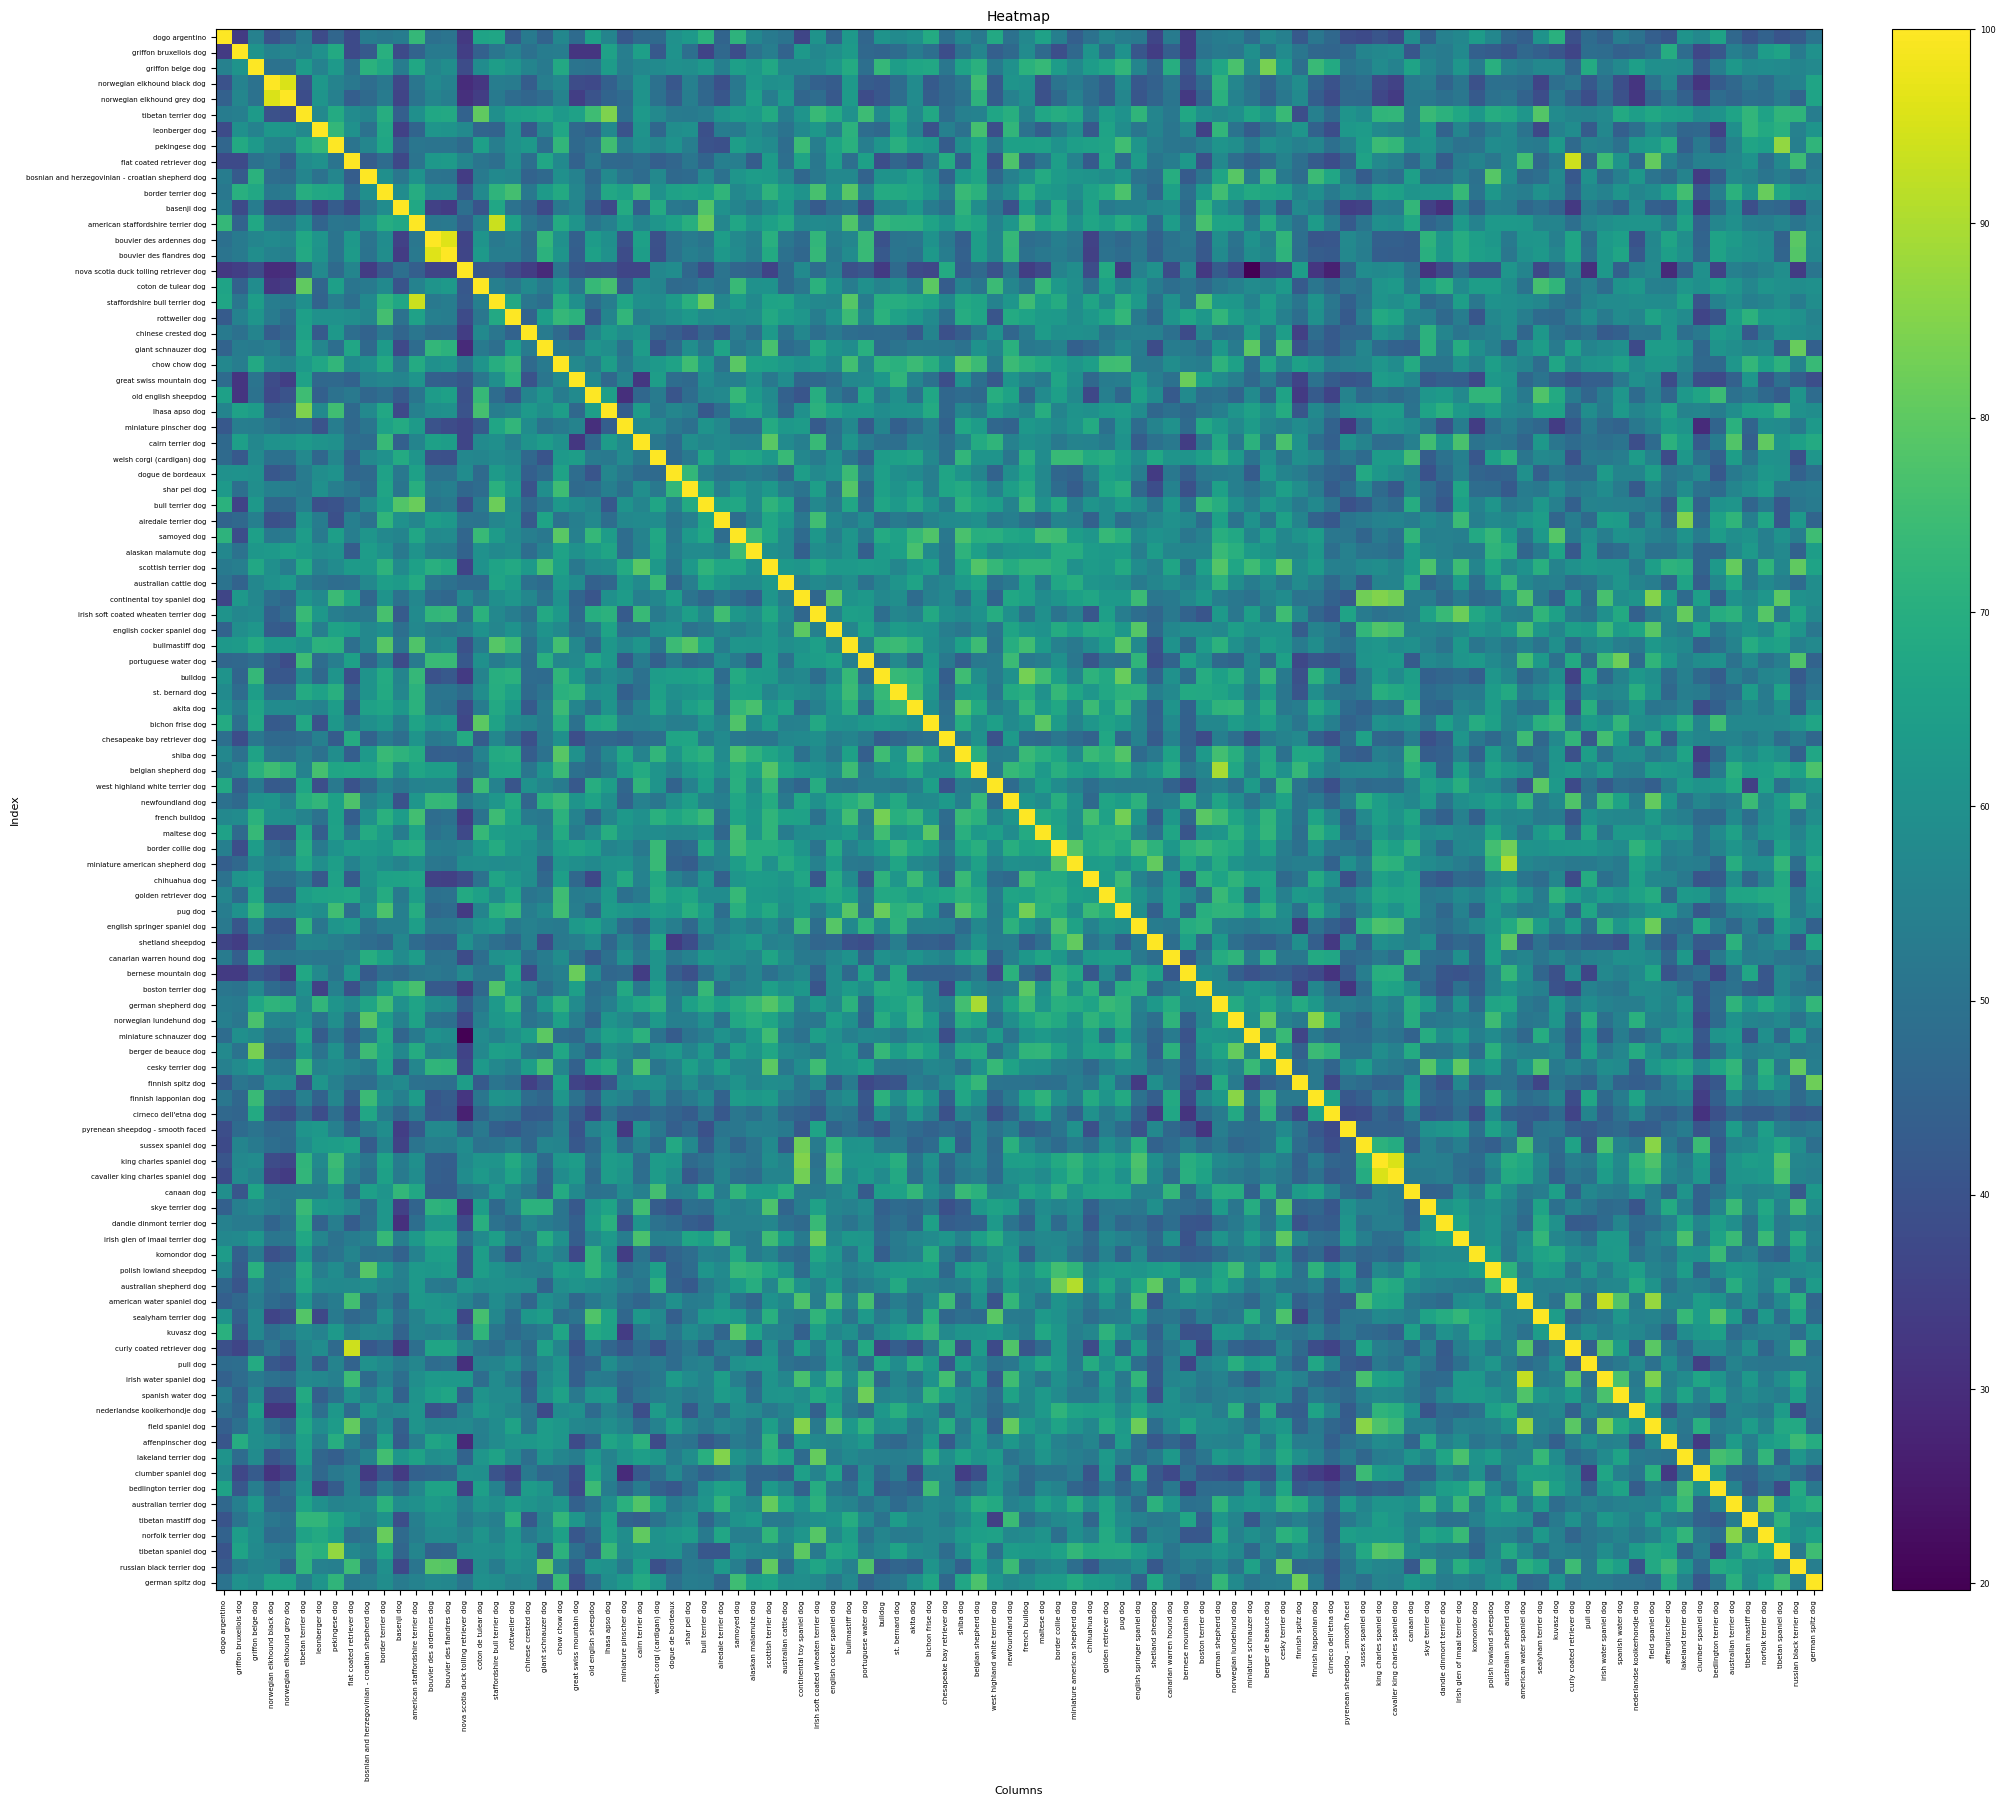

,dogo argentino,griffon bruxellois dog,griffon belge dog,norwegian elkhound black dog,norwegian elkhound grey dog,tibetan terrier dog,leonberger dog,pekingese dog,flat coated retriever dog,bosnian and herzegovinian - croatian shepherd dog,border terrier dog,basenji dog,american staffordshire terrier dog,bouvier des ardennes dog,bouvier des flandres dog,nova scotia duck tolling retriever dog,coton de tulear dog,staffordshire bull terrier dog,rottweiler dog,chinese crested dog,giant schnauzer dog,chow chow dog,great swiss mountain dog,old english sheepdog,lhasa apso dog,miniature pinscher dog,cairn terrier dog,welsh corgi (cardigan) dog,dogue de bordeaux,shar pei dog,bull terrier dog,airedale terrier dog,samoyed dog,alaskan malamute dog,scottish terrier dog,australian cattle dog,continental toy spaniel dog,irish soft coated wheaten terrier dog,english cocker spaniel dog,bullmastiff dog,portuguese water dog,bulldog,st. bernard dog,akita dog,bichon frise dog,chesapeake bay retriever dog,shiba dog,belgian shepherd dog,west highland white terrier dog,newfoundland dog,french bulldog,maltese dog,border collie dog,miniature american shepherd dog,chihuahua dog,golden retriever dog,pug dog,english springer spaniel dog,shetland sheepdog,canarian warren hound dog,bernese mountain dog,boston terrier dog,german shepherd dog,norwegian lundehund dog,miniature schnauzer dog,berger de beauce dog,cesky terrier dog,finnish spitz dog,finnish lapponian dog,cirneco dell'etna dog,pyrenean sheepdog - smooth faced,sussex spaniel dog,king charles spaniel dog,cavalier king charles spaniel dog,canaan dog,skye terrier dog,dandie dinmont terrier dog,irish glen of imaal terrier dog,komondor dog,polish lowland sheepdog,australian shepherd dog,american water spaniel dog,sealyham terrier dog,kuvasz dog,curly coated retriever dog,puli dog,irish water spaniel dog,spanish water dog,nederlandse kooikerhondje dog,field spaniel dog,affenpinscher dog,lakeland terrier dog,clumber spaniel dog,bedlington terrier dog,australian terrier dog,tibetan mastiff dog,norfolk terrier dog,tibetan spaniel dog,russian black terrier dog,german spitz dog
emitter,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
dogo argentino,100.000023,33.679951,54.839474,39.733990,44.657455,53.401302,38.107235,46.212772,37.667377,53.495621,51.819504,53.402199,73.135437,49.285995,50.465321,32.848072,66.379738,67.015831,42.828522,52.564865,45.100487,56.798183,47.889698,65.411667,55.854137,41.821171,47.070324,47.470535,60.292511,63.179443,70.812592,45.666500,71.499374,56.919540,52.842342,50.386494,36.461170,60.920631,45.115044,62.601574,46.303951,60.942017,57.942474,60.092049,68.708626,48.884190,56.968052,52.278160,68.090469,49.729893,57.301247,65.687195,54.477764,43.880524,50.036900,56.545387,53.648937,52.000416,36.278679,52.954643,33.699112,51.031269,53.387344,54.259636,48.172565,57.504028,54.617382,42.093643,51.371712,46.932220,38.797550,37.839611,40.706100,37.774624,59.338306,44.430191,55.023586,56.955837,63.686169,56.920849,46.384056,44.115784,61.039894,70.740562,39.411129,47.907032,44.538006,53.658463,50.079052,43.901810,41.090549,60.962139,57.234837,65.859131,46.741642,40.502991,45.039429,40.481312,42.556946,50.143124
griffon bruxellois dog,33.679951,99.999992,61.064510,55.142635,56.574123,54.458599,60.045563,68.599998,37.629173,42.467690,70.194534,37.815960,45.132427,52.819157,52.615559,34.600147,44.499619,51.280117,55.377777,49.727169,53.528870,53.563065,32.112728,32.122749,65.587952,53.894543,64.938164,42.108665,60.677124,49.042912,35.880123,46.723236,38.640232,49.962914,54.106068,45.195232,62.541218,56.878155,59.315563,63.565105,46.678165,45.824730,48.089363,53.453667,49.091858,38.652523,49.585892,56.060822,44.031448,46.956123,58.501572,47.533352,39.050175,46.728256,61.094154,47.599567,60.518158,41.042393,34.335674,44.020432,33.712101,50.248169,52.465607,51.417465,59.674599,50.336735,58.480705,51.121414,46.357620,45.735283,47.601543,55.989731,5

In [30]:
##############################
# Step 5: similarity matrix
##############################
#!rm "assets/similarity_clip_breeds.json"
df_similarities_clip = calculate_similarity_clip('breeds', restrict_labels)
plot_heatmap(df_similarities_clip)
df_similarities_clip.head()

## Person

In [31]:
from vision_unlearning.datasets import download_dataset_lfw, count_classes_dataset_lfw
from vision_unlearning.metrics import MetricRace

dataset_base_path = 'assets/datasets/lfw_splits'
dataset_base_path_filtered = 'assets/datasets/lfw_splits_filtered'

# Restart from step:
#!rm assets/metadata_people_1_enriched_but_not_filtered.json && rm assets/metadata_people_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
#!rm assets/metadata_people_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
#!rm -r {dataset_base_path_filtered}

#!rm -r {dataset_base_path}

#!rm "assets/similarity_clip_people.json"

In [32]:
##############################
# Step 1: prepare datasets
##############################

# Prepare unfiltered LFW
sorted_counts = count_classes_dataset_lfw()
for name, n in sorted_counts[:10]:
    print(f"{name}: {n}")

target = "all"  # No class separation, just to get properties for filtering
dataset_forget_name = f"{dataset_base_path}/{target}/train_forget"
dataset_retain_name = f"{dataset_base_path}/{target}/train_retain"

#!rm -r {dataset_base_path}
if not os.path.exists(dataset_base_path):
    download_dataset_lfw(dataset_forget_name, dataset_retain_name, target)

!find {dataset_forget_name} -type f | wc -l
!find {dataset_retain_name} -type f | wc -l
#!du -hs "{dataset_base_path}/{target}"

George_W_Bush: 530
Colin_Powell: 236
Tony_Blair: 144
Donald_Rumsfeld: 121
Gerhard_Schroeder: 109
Ariel_Sharon: 77
Hugo_Chavez: 71
Junichiro_Koizumi: 60
Jean_Chretien: 55
John_Ashcroft: 53


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


1


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


13234


In [33]:
df_pantheon = download_dataset_pantheon()

In [34]:
##############################
# Step 2: attribute inference
##############################

if os.path.exists('assets/metadata_people_1_enriched_but_not_filtered.json'):
    with open(f"assets/metadata_people_1_enriched_but_not_filtered.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
else:
    # Inicial set
    metadata = [{'name': name, 'dataset_n_original': n} for name, n in sorted_counts[:500]]

    # TODO: allow field-by-field inference, so we don't have to recalculate everyone when changing the code?

    # Attribute inference option 1: impossible, no labels in LFW
    
    # Attribute inference option 2: Pantheon
    logger.info('---------------- Enriching metadata with Pantheon')
    for entity in metadata:
        name_pantheon = pantheon_find_closest_match(df_pantheon, entity['name'])
        if name_pantheon is None:
            continue
        entity['name_pantheon'] = name_pantheon
    
        pantheon_row = df_pantheon[df_pantheon['slug']==entity['name_pantheon']].iloc[0]
        entity['birthyear'] = int(pantheon_row['birthyear'])
        entity['gender'] = pantheon_row['gender']
        entity['occupation'] = pantheon_row['occupation'].capitalize()
        entity['bplace_country'] = pantheon_row['bplace_country']
        entity['hpi'] = pantheon_row['hpi']
    
    # Attribute inference option 3: average value in some labeled dataset
    # TODO
    
    # Attribute inference option 4: data-driven with DeepFace
    logger.info('---------------- Enriching metadata with DeepFace')
    metric_race = MetricRace()
    for i, entity in enumerate(metadata):
        if i % 100 == 0:
            print(f"Enriched {i}...")
        # TODO: use multiple images, define race by majority voting
        img = Image.open(f"assets/datasets/lfw_splits/all/train_retain/{entity['name']}_0001.jpg")
        entity['race'] = metric_race.score(img)['race']

    # Save
    with open(f"assets/metadata_people_1_enriched_but_not_filtered.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

In [ ]:
##############################
# Step 3: filter
##############################
balanced_n = 100

#!rm assets/metadata_people_2_enriched_filtered.json && rm -r {dataset_base_path_filtered}
if os.path.exists('assets/metadata_people_2_enriched_filtered.json'):
    logger.info('Reading existing filtered data')
    with open(f"assets/metadata_people_2_enriched_filtered.json", "r", encoding="utf-8") as f:
        metadata_filtered = json.load(f)
else:
    logger.info('Filtering')
    with open(f"assets/metadata_people_1_enriched_but_not_filtered.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
    df = pd.DataFrame(metadata)
    #df.info()
    
    df['occupation_simplified'] = df['occupation']
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Actor', 'Artist')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Singer', 'Artist')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Musician', 'Artist')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Film director', 'Artist')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Comedian', 'Artist')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Writer', 'Artist')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Artist', 'Artist')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Model', 'Artist')
    
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Tennis player', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Basketball player', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Racing driver', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Swimmer', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Athlete', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Golfer', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Boxer', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Cyclist', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Skater', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Soccer player', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Baseball player ', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('American football player', 'Athlete')
    df['occupation_simplified'] = df['occupation_simplified'].str.replace('Cricketer', 'Athlete')
    df = df[df['occupation_simplified'].isin(['Politician', 'Artist', 'Athlete'])]
    print(df.value_counts('occupation_simplified'))
    
    df["hpi_bin"] = pd.qcut(
        df["hpi"],
        q=[0, 0.25, 0.5, 0.75, 1.0],
        labels=["Q0_25", "Q25_50", "Q50_75", "Q75_100"],
        duplicates="raise"
    )
    
    #df['race'] = df['race'].str.replace('indian', 'indian_middleEastern_latinoHispanic')
    #df['race'] = df['race'].str.replace('middle eastern', 'indian_middleEastern_latinoHispanic')
    #df['race'] = df['race'].str.replace('latino hispanic', 'indian_middleEastern_latinoHispanic')
    print(f'Number of unfiltered rows_ {len(df)}')
    
    df_balanced = balanced_subsample_lib(df, group_cols=['occupation_simplified', 'hpi_bin'], target=balanced_n, priority_col='dataset_n_original')
    
    print(df_balanced.value_counts('occupation_simplified'))
    print('-'*50)
    print(df_balanced.value_counts('hpi_bin'))
    print('-'*50)
    print(df_balanced.value_counts(['occupation_simplified', 'hpi_bin']))
    
    #df[(df['gender']=='F') & (df['race']=='black')]  # There are just 6 black woman, which can't be balanced
    metadata_filtered = df_balanced.to_dict(orient='records')

    with open(f"assets/metadata_people_2_enriched_filtered.json", "w", encoding="utf-8") as f:
        json.dump(metadata_filtered, f, indent=2)

assert type(metadata_filtered) == list
assert len(metadata_filtered) == balanced_n
assert metadata_filtered[0]['name'] == 'George_W_Bush', 'I think your size-priotity is wrong'

[2025-11-07 22:11:06 +0100] vision_unlearning.datasets INFO     Reading existing filtered data


In [ ]:
##############################
# Step 4: save splits
##############################
smallest_entity = min([entity['dataset_n_original'] for entity in metadata_filtered])
restrict_labels = [e['name'] for e in metadata_filtered]
logger.info(f"We have {balanced_n} identities, each one with {smallest_entity} images")

#!rm -r {dataset_base_path_filtered}
if not os.path.exists(dataset_base_path_filtered):
    for i, target in enumerate(restrict_labels):
        logger.info(f"Saving split dataset for entity {i}: {target}")
        dataset_forget_name = f"{dataset_base_path_filtered}/{target}/train_forget"
        dataset_retain_name = f"{dataset_base_path_filtered}/{target}/train_retain"
        class_to_number = download_dataset_lfw(  # TODO use symlinks, just like split_dataset_sun and split_dataset_taras_breeds
            dataset_forget_name,
            dataset_retain_name,
            target,
            forget_max_img = smallest_entity,
            retain_max_img_per_class= smallest_entity,
            restrict_labels = restrict_labels,
        )
        assert sum([v>0 for v in class_to_number.values()]) == balanced_n, 'More entities than expected were saved'
        assert sum([v==smallest_entity for v in class_to_number.values()]) == balanced_n, 'Not all entities have the same number of images'
        assert target in class_to_number.keys()
    
        assert sum(len(files) for _, _, files in os.walk(dataset_forget_name)) == smallest_entity+1
        assert sum(len(files) for _, _, files in os.walk(dataset_retain_name)) == (balanced_n-1)*smallest_entity+1

# Each identity has about 4.4Mb
#!du -hs "{dataset_base_path_filtered}/{target}"

#!find {dataset_forget_name} -type f | wc -l
#!find {dataset_retain_name} -type f | wc -l

[2025-11-07 22:11:08 +0100] vision_unlearning.datasets INFO     We have 100 identities, each one with 5 images


In [37]:
!ls assets/datasets/lfw_splits_filtered/George_W_Bush/train_forget

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


George_W_Bush_0344.jpg	George_W_Bush_0387.jpg	George_W_Bush_0422.jpg
George_W_Bush_0378.jpg	George_W_Bush_0393.jpg	metadata.jsonl


In [38]:
!ls assets/datasets/lfw_splits_filtered/George_W_Bush/train_retain

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Adrien_Brody_0005.jpg		  Junichiro_Koizumi_0051.jpg
Adrien_Brody_0006.jpg		  Junichiro_Koizumi_0052.jpg
Adrien_Brody_0007.jpg		  Justin_Timberlake_0002.jpg
Adrien_Brody_0011.jpg		  Justin_Timberlake_0004.jpg
Adrien_Brody_0012.jpg		  Justin_Timberlake_0005.jpg
Alejandro_Toledo_0001.jpg	  Justin_Timberlake_0006.jpg
Alejandro_Toledo_0014.jpg	  Justin_Timberlake_0007.jpg
Alejandro_Toledo_0015.jpg	  Kate_Hudson_0001.jpg
Alejandro_Toledo_0028.jpg	  Kate_Hudson_0002.jpg
Alejandro_Toledo_0029.jpg	  Kate_Hudson_0003.jpg
Amelia_Vega_0001.jpg		  Kate_Hudson_0008.jpg
Amelia_Vega_0002.jpg		  Kate_Hudson_0009.jpg
Amelia_Vega_0003.jpg		  Kim_Clijsters_0005.jpg
Amelia_Vega_0006.jpg		  Kim_Clijsters_0006.jpg
Amelia_Vega_0007.jpg		  Kim_Clijsters_0007.jpg
Andre_Agassi_0001.jpg		  Kim_Clijsters_0012.jpg
Andre_Agassi_0014.jpg		  Kim_Clijsters_0013.jpg
Andre_Agassi_0015.jpg		  Lance_Armstrong_0002.jpg
Andre_Agassi_0028.jpg		  Lance_Armstrong_0003.jpg
Andre_Agassi_0029.jpg		  Lance_Armstrong_0014.jpg
Andy_R

Analying similarities for entity_emitter=George_W_Bush
Analying similarities for entity_emitter=Colin_Powell
Analying similarities for entity_emitter=Tony_Blair
Analying similarities for entity_emitter=Donald_Rumsfeld
Analying similarities for entity_emitter=Ariel_Sharon
Analying similarities for entity_emitter=Junichiro_Koizumi
Analying similarities for entity_emitter=John_Ashcroft
Analying similarities for entity_emitter=Jacques_Chirac
Analying similarities for entity_emitter=Serena_Williams
Analying similarities for entity_emitter=Vladimir_Putin
Analying similarities for entity_emitter=Gloria_Macapagal_Arroyo
Analying similarities for entity_emitter=Arnold_Schwarzenegger
Analying similarities for entity_emitter=Jennifer_Capriati
Analying similarities for entity_emitter=Lleyton_Hewitt
Analying similarities for entity_emitter=Laura_Bush
Analying similarities for entity_emitter=Alejandro_Toledo
Analying similarities for entity_emitter=Andre_Agassi
Analying similarities for entity_emitt

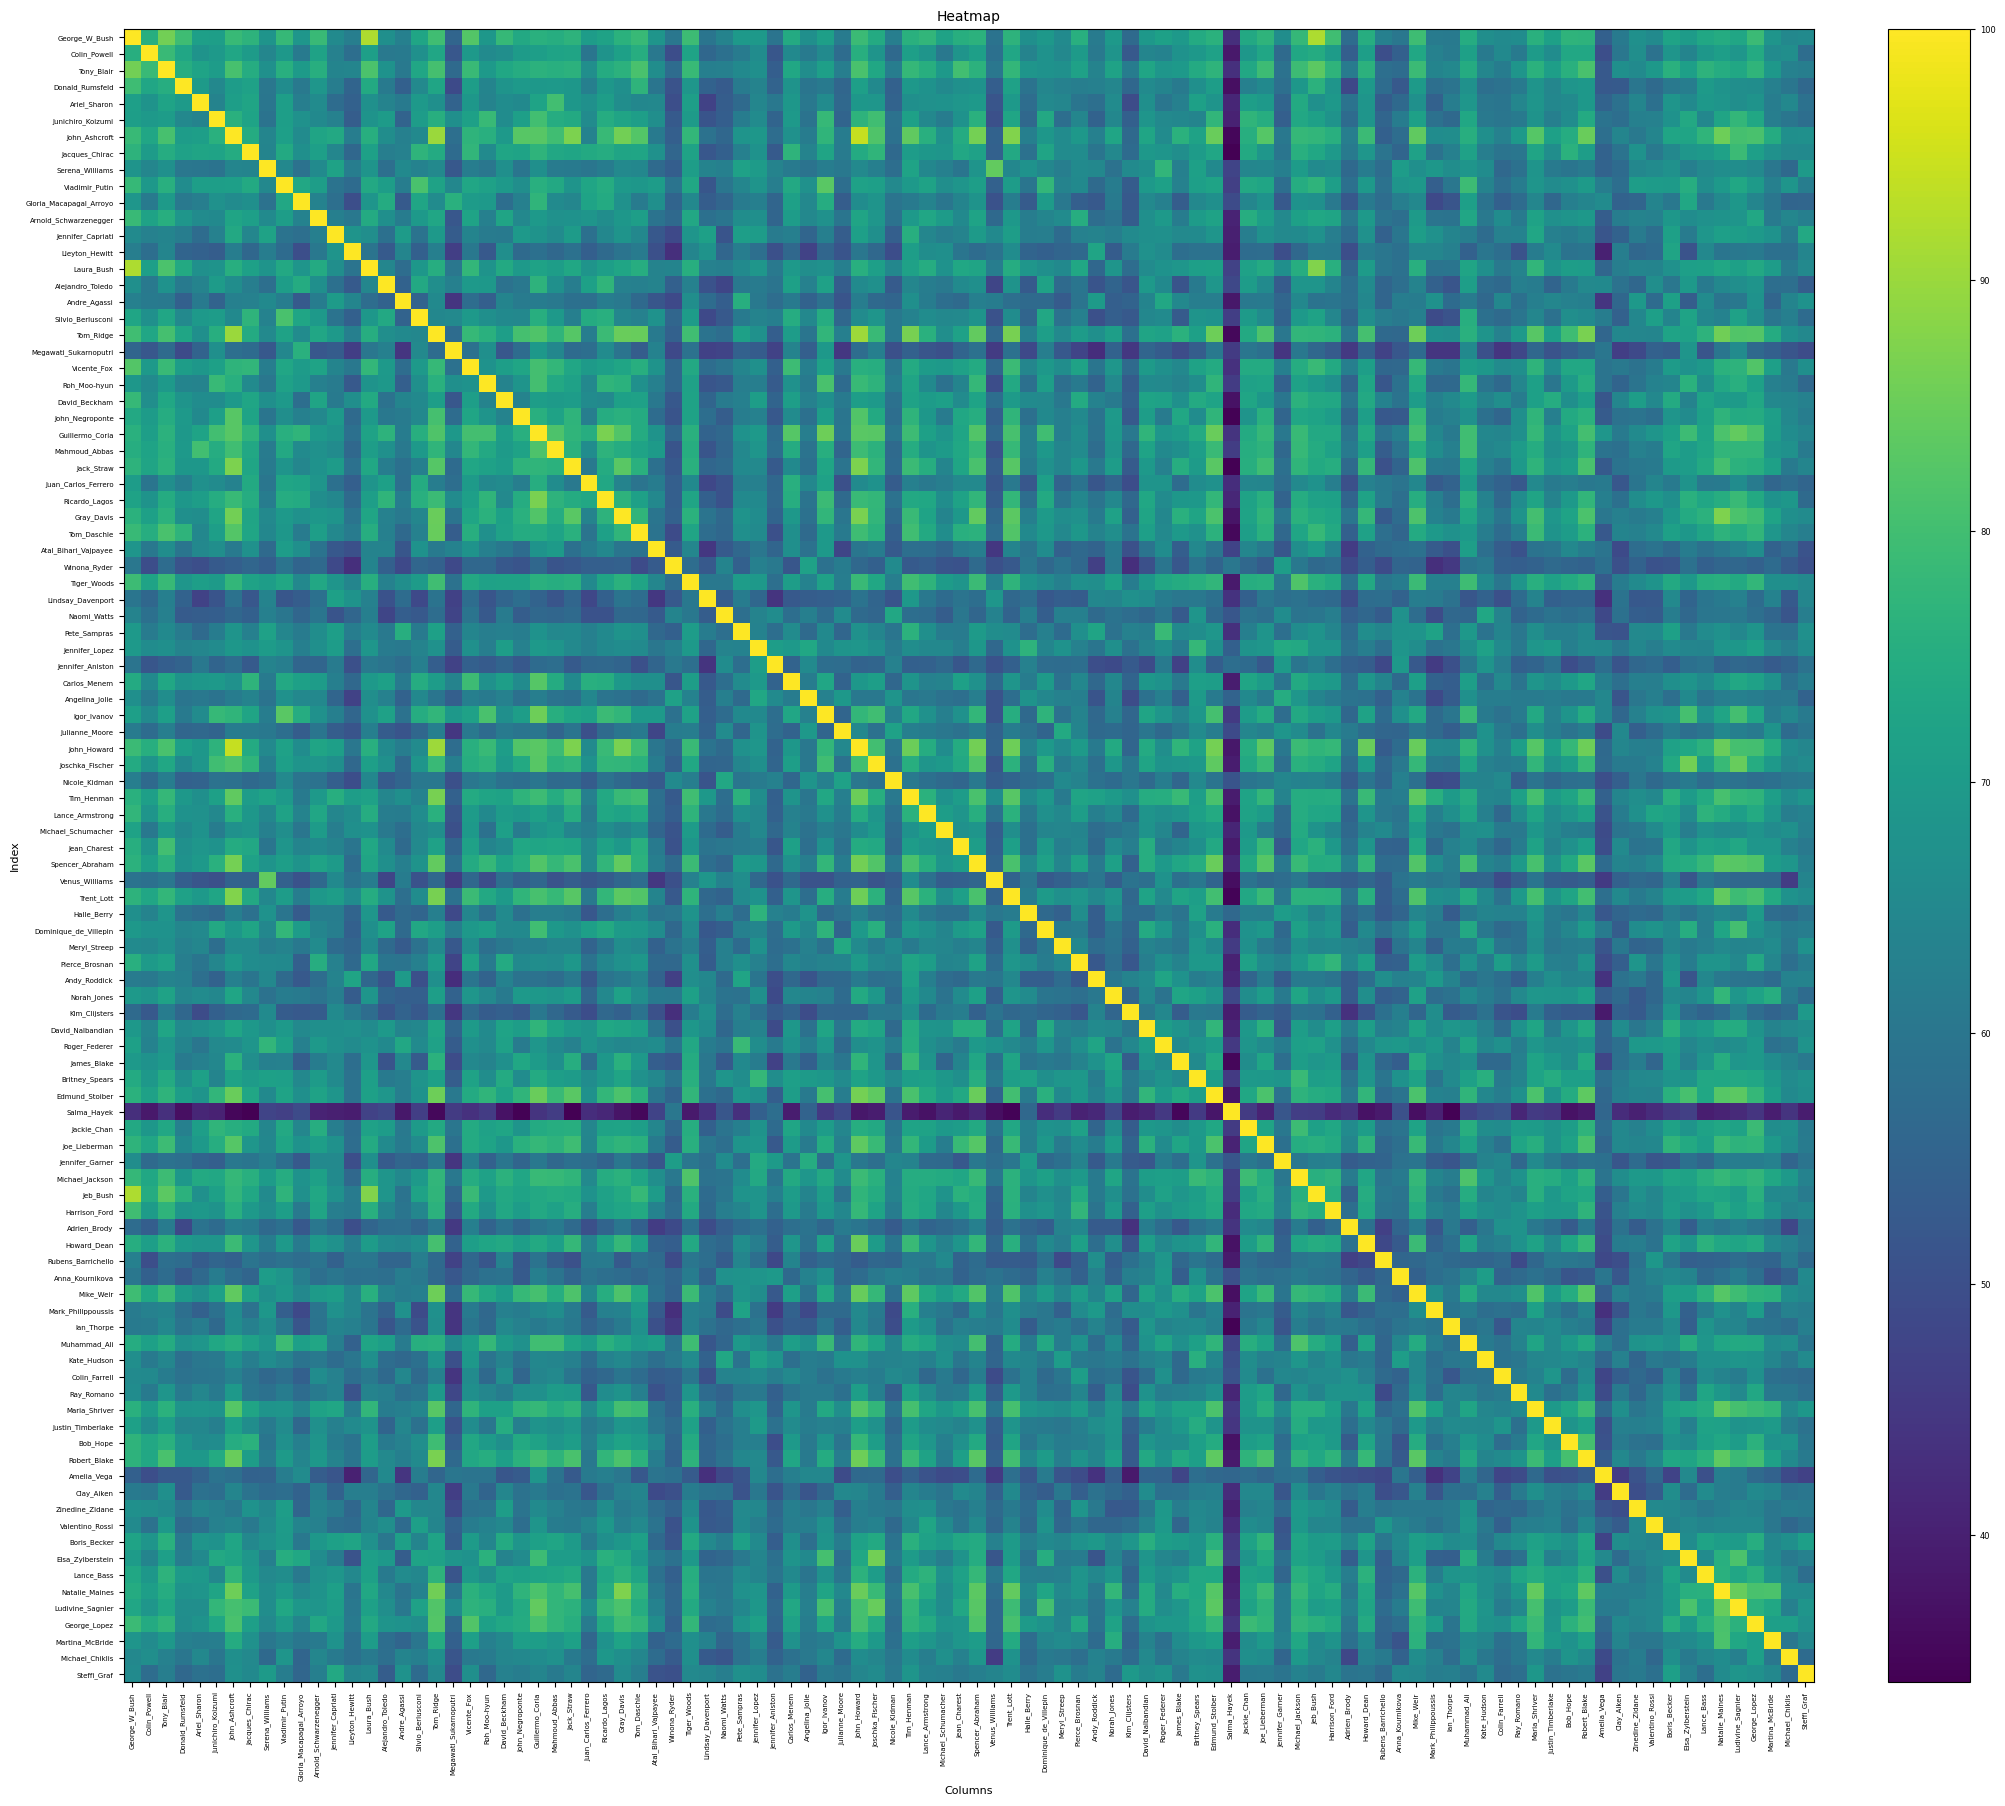

,George_W_Bush,Colin_Powell,Tony_Blair,Donald_Rumsfeld,Ariel_Sharon,Junichiro_Koizumi,John_Ashcroft,Jacques_Chirac,Serena_Williams,Vladimir_Putin,Gloria_Macapagal_Arroyo,Arnold_Schwarzenegger,Jennifer_Capriati,Lleyton_Hewitt,Laura_Bush,Alejandro_Toledo,Andre_Agassi,Silvio_Berlusconi,Tom_Ridge,Megawati_Sukarnoputri,Vicente_Fox,Roh_Moo-hyun,David_Beckham,John_Negroponte,Guillermo_Coria,Mahmoud_Abbas,Jack_Straw,Juan_Carlos_Ferrero,Ricardo_Lagos,Gray_Davis,Tom_Daschle,Atal_Bihari_Vajpayee,Winona_Ryder,Tiger_Woods,Lindsay_Davenport,Naomi_Watts,Pete_Sampras,Jennifer_Lopez,Jennifer_Aniston,Carlos_Menem,Angelina_Jolie,Igor_Ivanov,Julianne_Moore,John_Howard,Joschka_Fischer,Nicole_Kidman,Tim_Henman,Lance_Armstrong,Michael_Schumacher,Jean_Charest,Spencer_Abraham,Venus_Williams,Trent_Lott,Halle_Berry,Dominique_de_Villepin,Meryl_Streep,Pierce_Brosnan,Andy_Roddick,Norah_Jones,Kim_Clijsters,David_Nalbandian,Roger_Federer,James_Blake,Britney_Spears,Edmund_Stoiber,Salma_Hayek,Jackie_Chan,Joe_Lieberman,Jennifer_Garner,Michael_Jackson,Jeb_Bush,Harrison_Ford,Adrien_Brody,Howard_Dean,Rubens_Barrichello,Anna_Kournikova,Mike_Weir,Mark_Philippoussis,Ian_Thorpe,Muhammad_Ali,Kate_Hudson,Colin_Farrell,Ray_Romano,Maria_Shriver,Justin_Timberlake,Bob_Hope,Robert_Blake,Amelia_Vega,Clay_Aiken,Zinedine_Zidane,Valentino_Rossi,Boris_Becker,Elsa_Zylberstein,Lance_Bass,Natalie_Maines,Ludivine_Sagnier,George_Lopez,Martina_McBride,Michael_Chiklis,Steffi_Graf
emitter,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
George_W_Bush,100.000015,75.432571,85.869469,79.555023,71.205765,71.030930,78.520081,76.772331,68.280998,78.358757,68.720337,78.803230,65.628769,62.336945,91.794167,66.939346,62.778057,72.742599,79.921814,55.516331,82.257347,69.109604,78.155312,73.883324,75.820564,75.110626,76.748085,70.564873,72.091034,76.121170,78.479111,68.491623,60.141109,79.224854,59.799248,63.537033,69.749260,69.854340,59.569950,74.398109,66.974159,71.191811,61.542152,78.928795,74.361076,62.421906,75.956436,77.520767,72.011551,75.430893,76.531639,59.177719,76.667465,66.933022,69.244301,65.604652,75.814430,61.530094,69.664612,56.841839,69.315247,71.629051,69.750130,74.498680,76.287918,42.980236,73.801491,76.973099,66.526520,78.130951,91.817070,79.905762,57.340752,75.077499,62.784023,60.367710,79.645668,61.411953,61.266964,74.934143,66.758362,65.674355,66.121964,75.956947,71.695984,76.986443,76.823601,54.364460,61.125977,67.252716,65.620972,72.422249,70.281776,73.319504,74.751350,73.017952,79.047760,68.444321,64.952484,65.561455
Colin_Powell,75.432571,100.000000,78.807793,73.040779,67.866653,69.654869,73.212875,70.229027,64.495949,69.130653,61.337852,72.143295,63.200413,57.846325,71.358665,60.687901,60.971523,67.277756,73.184769,52.099373,69.544250,65.609047,66.675949,70.303650,71.165695,72.319214,72.520584,59.661015,67.904579,71.571655,75.287460,60.633682,49.720741,72.406975,56.173698,58.535755,61.618584,66.133293,51.714092,65.363274,61.316185,65.645203,57.427048,75.347939,68.298729,56.614315,71.205482,68.579063,60.517155,68.318619,71.239098,58.485634,73.235298,63.602818,67.608299,64.912979,69.985634,60.647057,68.143272,52.533287,64.167068,63.281696,67.720673,69.137489,71.858635,38.722221,68.980873,73.005203,56.921364,73.446724,74.625374,70.206505,53.749786,70.972153,50.019287,54.222511,73.466820,63.017822,61.630112,71.445847,61.224972,65.444221,60.950012,70.338394,66.105568,73.556915,73.598160,49.855507,60.129528,66.713379,58.865910,68.388786,63.901741,69.008781,71.167580,68.856804,74.485962,65.936348,66.578323,57.798885
Tony_Blair,85.869469,78.807793,100.000000,75.193222,72.423805,70.606308,80.879761,74.900230,67.151520,75.760880,69.960060,75.509293,63.773376,64.165565,81.267700,67.673996,60.748405,73.090332,80.659203,56.975948,78.665245,69.663391,73.419418,74.806824,76.565430,75.679565,76.584206,66.687904,74.781944,76.523605,81.020355,66.339294,57.331032,78.447395,62.602806,62.918163,65.503540,66.974533,53.937477,73.263969,66.4691

In [39]:
##############################
# Step 5: similarity matrix
##############################
#!rm "assets/similarity_clip_people.json"
df_similarities_clip = calculate_similarity_clip('people', restrict_labels)
plot_heatmap(df_similarities_clip)
df_similarities_clip.head()